# SKIPP'D — PV Power EDA

**SKIPP'D** (Stanford Sky Images + Photovoltaic Power) is a benchmark for
*short-term* (minute-level) solar forecasting from a fisheye sky camera plus a
30 kW rooftop PV array. This notebook explores **only the PV power time series**
(`labels/`), which is small and fast; the 2.2 GB sky-image parquets (`data/`)
are left for a separate image EDA.

Self-contained: reads the parquet directly, no `src/helper` (the GEFCom loader /
feature builder are GEFCom-specific and do not apply to SKIPP'D). If the cleaning
steps here stabilise, they can later be lifted into a reusable `SKIPPD` loader.

## `data/` vs `labels/` — what's the difference?

The dataset ships as two mirrored parquet sets:

- **`data/`** — `image` + `time` + `pv` (2.2 GB, 5 train shards). The sky photo per timestamp.
- **`labels/`** — `time` + `pv` only (4 MB, 1 shard). The same rows with the image dropped.

This EDA uses **`labels/`** (fast, all the power information). The cell below confirms the
two are row-aligned with **identical `time` / `pv`**, so nothing is lost by skipping `data/`;
the only extra it carries is the `image` column, needed only for image / multimodal modelling.

In [1]:
import glob
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path

ROOT = Path("/Users/lin_/Solar_Prediction/data/raw/SKIPPD")

def summary(pattern):
    files = sorted(glob.glob(str(ROOT / pattern)))
    rows = sum(pq.ParquetFile(f).metadata.num_rows for f in files)
    cols = [f.name for f in pq.ParquetFile(files[0]).schema_arrow]
    return len(files), rows, cols

for name, pat in [("data  ", "data/train-*.parquet"), ("labels", "labels/train-*.parquet")]:
    n, rows, cols = summary(pat)
    print(f"{name}: {n} shard(s) | {rows:,} rows | cols = {cols}")

# Same underlying series? Join the first data shard (time+pv only, image bytes skipped)
# to labels on `time`; data/ differs only by carrying the `image` column.
d = pq.ParquetFile(str(ROOT / "data/train-00000-of-00005.parquet")).read(columns=["time", "pv"]).to_pandas()
l = pd.read_parquet(ROOT / "labels/train-00000-of-00001.parquet", columns=["time", "pv"])
m = d.merge(l, on="time", suffixes=("_data", "_labels"))
print(f"\nfirst data shard: {len(d):,} rows | matched to labels on time: {len(m):,} "
      f"| pv identical: {(m.pv_data == m.pv_labels).all()}")

data  : 5 shard(s) | 349,372 rows | cols = ['image', 'time', 'pv']
labels: 1 shard(s) | 349,372 rows | cols = ['time', 'pv']

first data shard: 69,875 rows | matched to labels on time: 69,875 | pv identical: True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (11, 4)
LABELS = Path("/Users/lin_/Solar_Prediction/data/raw/SKIPPD/labels")

def load_split(name):
    """Load one labels split and add local-time calendar helper columns.

    `time` is tz-aware US/Pacific already, so hour/date are true local values
    (DST handled by pandas; the raw data mixes -08:00 and -07:00 offsets)."""
    df = pd.read_parquet(LABELS / f"{name}-00000-of-00001.parquet")
    df = df.sort_values("time").reset_index(drop=True)
    t = df["time"].dt.tz_convert("US/Pacific")
    df["date"] = t.dt.normalize()
    df["year"] = t.dt.year
    df["month"] = t.dt.month
    df["doy"] = t.dt.dayofyear
    df["hour"] = t.dt.hour
    df["minute_of_day"] = t.dt.hour * 60 + t.dt.minute
    df["split"] = name
    return df

train = load_split("train")
test = load_split("test")
print("train", train.shape, "| test", test.shape)
train.head()

train (349372, 9) | test (14003, 9)


,time,pv,date,year,month,doy,hour,minute_of_day,split
0,2017-03-09 06:47:00-08:00,0.055691,2017-03-09 00:00:00-08:00,2017,3,68,6,407,train
1,2017-03-09 06:48:00-08:00,0.088763,2017-03-09 00:00:00-08:00,2017,3,68,6,408,train
2,2017-03-09 06:49:00-08:00,0.109171,2017-03-09 00:00:00-08:00,2017,3,68,6,409,train
3,2017-03-09 06:50:00-08:00,0.123206,2017-03-09 00:00:00-08:00,2017,3,68,6,410,train
4,2017-03-09 06:51:00-08:00,0.159748,2017-03-09 00:00:00-08:00,2017,3,68,6,411,train


## 0. Overview

Schema, size, and the PV target's units/range. Note `pv` is in **kW (0–~30),
raw — not normalised to [0, 1]** like the GEFCom target.

In [3]:
print("dtypes:")
print(train.dtypes, "\n")
for name, df in [("train", train), ("test", test)]:
    print(f"[{name}] rows={len(df):,}  days={df.date.nunique()}  "
          f"span {df.time.min()}  ->  {df.time.max()}")
print("\npv (kW) summary — train:")
print(train.pv.describe())
print("\ntrain memory (MB):", round(train.memory_usage(deep=True).sum() / 1e6, 1))

dtypes:
time             datetime64[ms, US/Pacific]
pv                                  float32
date             datetime64[ms, US/Pacific]
year                                  int32
month                                 int32
doy                                   int32
hour                                  int32
minute_of_day                         int32
split                                object
dtype: object 

[train] rows=349,372  days=497  span 2017-03-09 06:47:00-08:00  ->  2019-10-26 18:59:20-07:00
[test] rows=14,003  days=20  span 2017-06-24 07:38:40-07:00  ->  2019-10-19 19:15:30-07:00

pv (kW) summary — train:
count    349372.000000
mean         13.277490
std           7.929324
min           0.000020
25%           5.734100
50%          14.559606
75%          20.587707
max          29.585369
Name: pv, dtype: float64

train memory (MB): 35.6


## 1. Temporal coverage & sampling cadence

Nominal cadence is **1 minute, daytime only** (nights are absent, so every day is
its own contiguous block). Here we quantify how regular the steps are and how
many days are missing.

within-day step (s): median 60.0 | 1%..99%: 60.0 60.0
share of exact 60 s steps: 99.24 %
gaps > 1 h: 535 | gaps > 1 day: 40 | largest gap (days): 99.6


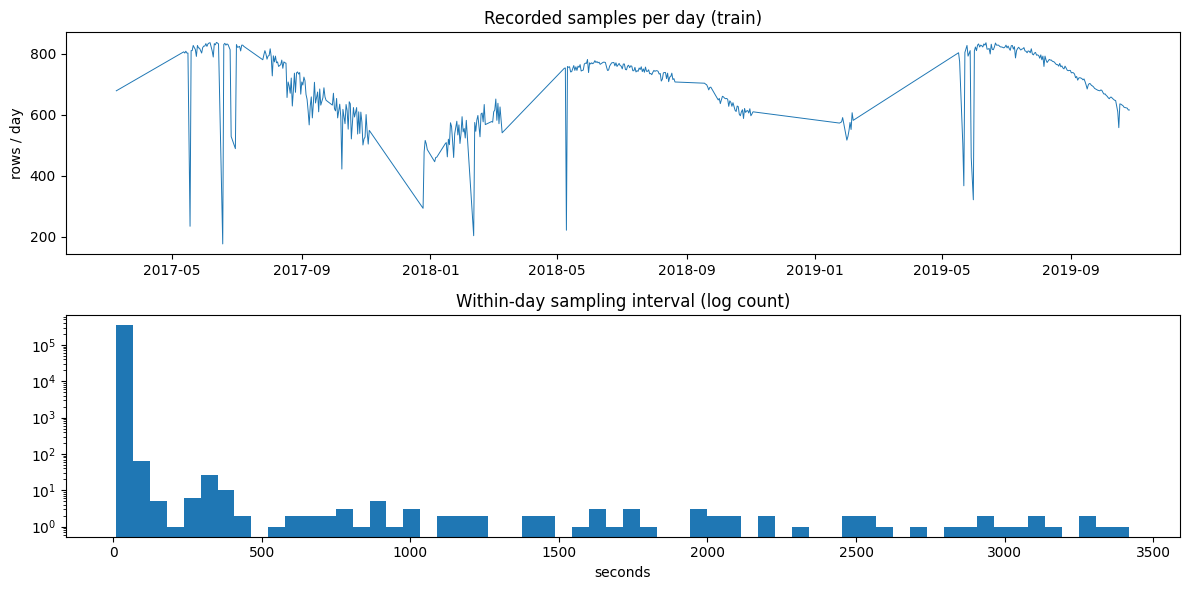

In [4]:
dt = train["time"].diff().dt.total_seconds()
within = dt[(dt > 0) & (dt < 3600)]         # steps inside a day
print("within-day step (s): median", within.median(),
      "| 1%..99%:", within.quantile(.01), within.quantile(.99))
print("share of exact 60 s steps:", round((within == 60).mean() * 100, 2), "%")
print("gaps > 1 h:", int((dt > 3600).sum()),
      "| gaps > 1 day:", int((dt > 86400).sum()),
      "| largest gap (days):", round(dt.max() / 86400, 1))

per_day = train.groupby("date").size()
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
ax[0].plot(per_day.index, per_day.values, lw=.7)
ax[0].set_title("Recorded samples per day (train)"); ax[0].set_ylabel("rows / day")
ax[1].hist(within, bins=60, log=True)
ax[1].set_title("Within-day sampling interval (log count)"); ax[1].set_xlabel("seconds")
plt.tight_layout(); plt.show()

## 2. Nature of the train / test split

A common assumption is that the official split is chronological — it is **not**.
The date *ranges* overlap, but train and test are **disjoint whole days** sampled
across the same span (a day-level hold-out). We verify there is no timestamp or
day overlap, so there is no direct leakage from this split itself.

overlapping calendar days (train ∩ test): 0
exact-timestamp overlap rows: 0
train: 497 days | test: 20 held-out days


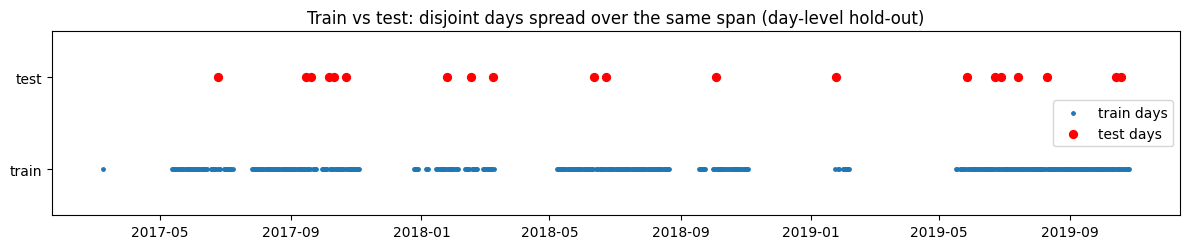

In [5]:
tr_days, te_days = set(train.date.unique()), set(test.date.unique())
print("overlapping calendar days (train ∩ test):", len(tr_days & te_days))
print("exact-timestamp overlap rows:",
      len(pd.Index(train.time).intersection(pd.Index(test.time))))
print(f"train: {len(tr_days)} days | test: {len(te_days)} held-out days")

fig, ax = plt.subplots(figsize=(12, 2.6))
ax.scatter(sorted(tr_days), [0] * len(tr_days), s=6, label="train days")
ax.scatter(sorted(te_days), [1] * len(te_days), s=32, c="red", label="test days")
ax.set_yticks([0, 1]); ax.set_yticklabels(["train", "test"])
ax.set_ylim(-.5, 1.5); ax.legend(loc="center right")
ax.set_title("Train vs test: disjoint days spread over the same span (day-level hold-out)")
plt.tight_layout(); plt.show()

## 3. PV power distribution

Overall distribution and the average diurnal shape. The 10–90% band shows how
much cloud cover spreads power around the clear-sky envelope at each hour.

assumed capacity ~ max observed pv: 29.59 kW


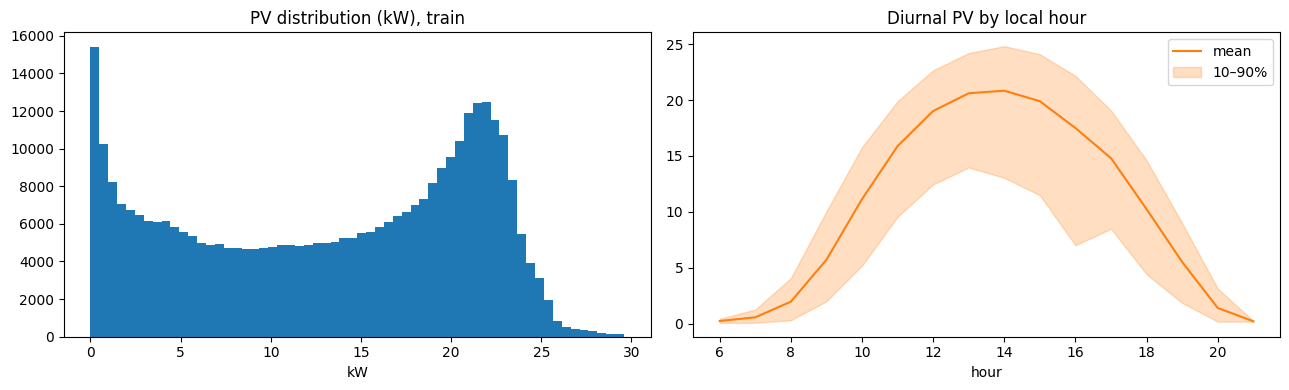

In [6]:
cap = train.pv.max()
print("assumed capacity ~ max observed pv:", round(cap, 2), "kW")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(train.pv, bins=60)
ax[0].set_title("PV distribution (kW), train"); ax[0].set_xlabel("kW")

by_hour = train.groupby("hour").pv
mean = by_hour.mean()
ax[1].plot(mean.index, mean.values, label="mean", color="C1")
ax[1].fill_between(mean.index, by_hour.quantile(.1).values, by_hour.quantile(.9).values,
                   alpha=.25, color="C1", label="10–90%")
ax[1].set_title("Diurnal PV by local hour"); ax[1].set_xlabel("hour"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. Diurnal × seasonal structure

Mean PV over hour-of-day × month shows the seasonal envelope (longer, stronger
summer days). Recorded daytime minutes vs day-of-year traces the day-length
curve; daily-mean PV vs day-of-year shows the seasonal + weather scatter.

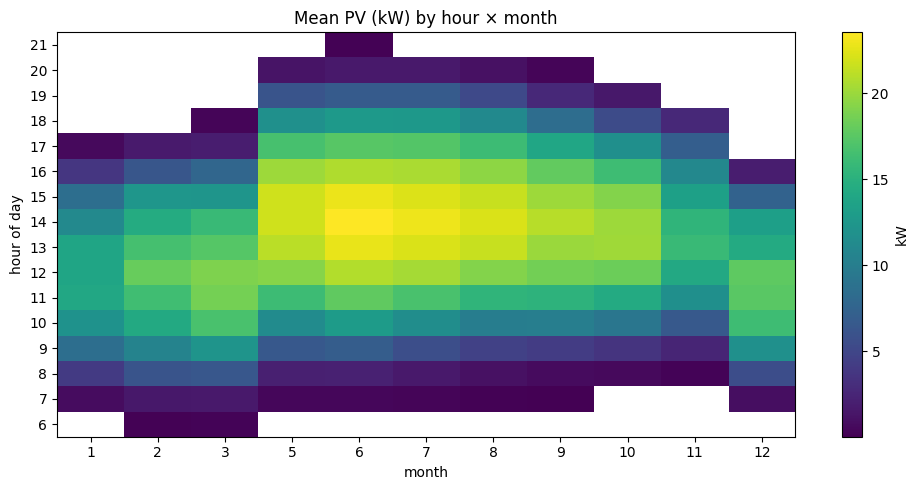

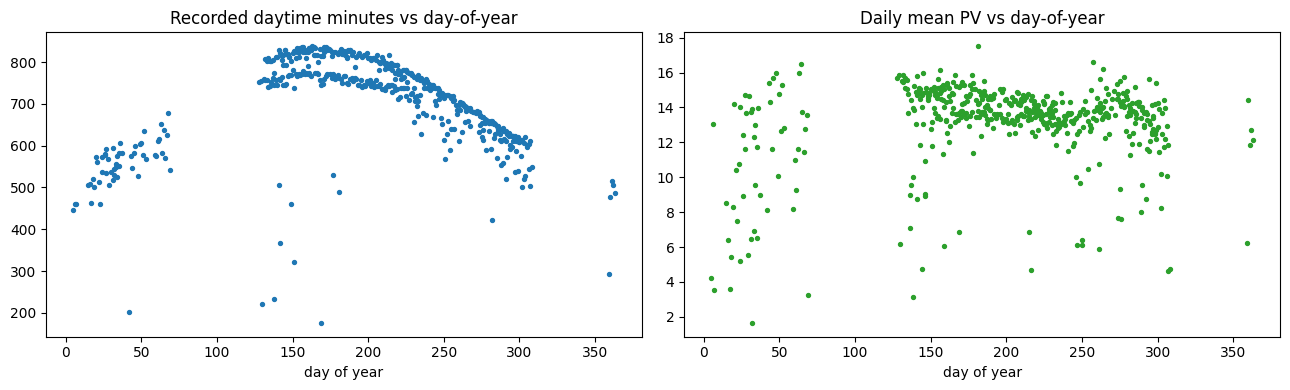

In [7]:
piv = train.pivot_table(index="hour", columns="month", values="pv", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(piv.values, aspect="auto", origin="lower", cmap="viridis")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
ax.set_xlabel("month"); ax.set_ylabel("hour of day")
ax.set_title("Mean PV (kW) by hour × month")
fig.colorbar(im, label="kW"); plt.tight_layout(); plt.show()

daily = train.groupby("date").agg(minutes=("pv", "size"),
                                  mean_pv=("pv", "mean"), doy=("doy", "first"))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(daily.doy, daily.minutes, s=8)
ax[0].set_title("Recorded daytime minutes vs day-of-year"); ax[0].set_xlabel("day of year")
ax[1].scatter(daily.doy, daily.mean_pv, s=8, color="C2")
ax[1].set_title("Daily mean PV vs day-of-year"); ax[1].set_xlabel("day of year")
plt.tight_layout(); plt.show()

## 5. Minute-level variability (cloud ramps)

The reason SKIPP'D pairs power with sky images: minute-to-minute **ramps** driven
by passing clouds. We measure 1-minute ramps (only across true 60 s steps), then
contrast the calmest vs the most volatile day by ramp std as clear/cloudy
examples.

1-min ramp (kW): std 0.91 | p1/p99: -2.7 2.78 | max |ramp|: 22.12


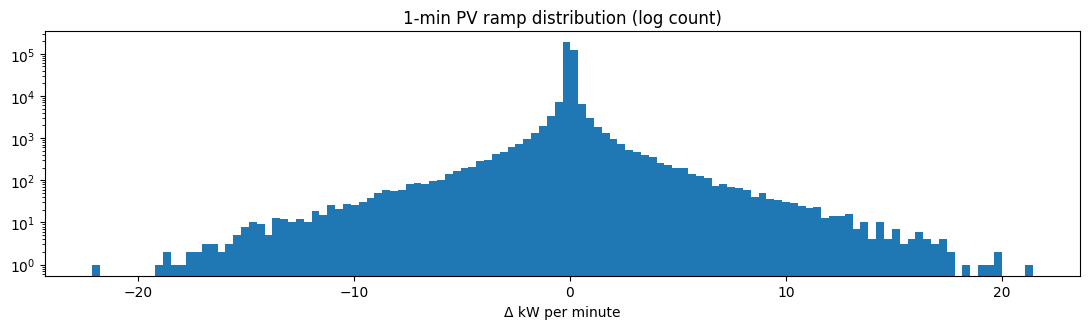

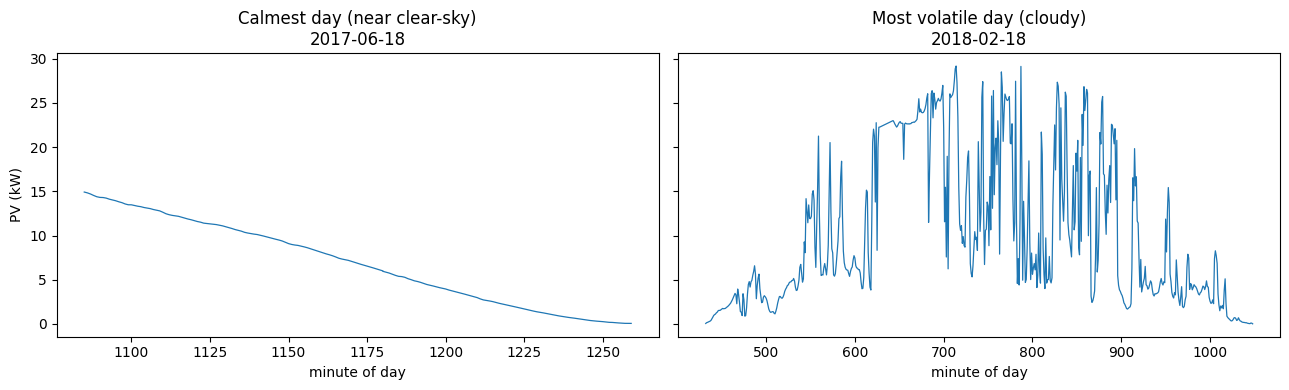

In [8]:
step = train["time"].diff().dt.total_seconds()
ramp = train.pv.diff().where(step == 60)
print("1-min ramp (kW): std", round(ramp.std(), 3),
      "| p1/p99:", round(ramp.quantile(.01), 2), round(ramp.quantile(.99), 2),
      "| max |ramp|:", round(ramp.abs().max(), 2))

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.hist(ramp.dropna(), bins=120, log=True)
ax.set_title("1-min PV ramp distribution (log count)"); ax.set_xlabel("Δ kW per minute")
plt.tight_layout(); plt.show()

day_var = train.assign(ramp=ramp).groupby("date").ramp.std()
clear_day, cloudy_day = day_var.idxmin(), day_var.idxmax()
fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for a, day, title in [(ax[0], clear_day, "Calmest day (near clear-sky)"),
                      (ax[1], cloudy_day, "Most volatile day (cloudy)")]:
    d = train[train.date == day]
    a.plot(d.minute_of_day, d.pv, lw=.9)
    a.set_title(f"{title}\n{pd.Timestamp(day).date()}"); a.set_xlabel("minute of day")
ax[0].set_ylabel("PV (kW)")
plt.tight_layout(); plt.show()

## 6. Data-quality summary

Nulls, duplicate/monotonic timestamps, sign of PV, and saturation at capacity.

In [9]:
print("nulls per column:", train[["time", "pv"]].isna().sum().to_dict())
print("duplicate timestamps:", int(train.time.duplicated().sum()))
print("time monotonic increasing:", bool(train.time.is_monotonic_increasing))
print("pv <= 0:", int((train.pv <= 0).sum()), "| pv < 0:", int((train.pv < 0).sum()))
print("pv within 1% of capacity:", int((train.pv >= 0.99 * cap).sum()))

nulls per column: {'time': 0, 'pv': 0}
duplicate timestamps: 0
time monotonic increasing: True
pv <= 0: 0 | pv < 0: 0
pv within 1% of capacity: 92


## Takeaways

- **Target**: PV power in **kW, ~0–30, raw** (not [0,1]); strictly positive — nights
  already removed, so the series is **daytime-only, one block per day**.
- **Cadence**: ~1-minute, overwhelmingly exact 60 s steps; a minority of shorter
  irregular steps and **40 multi-day gaps** (missing days) — windows for modelling
  must not cross day/gap boundaries.
- **Split**: official train/test are **disjoint days over the same span**, not a
  chronological cut — no direct leakage, but also not a forward-in-time evaluation.
- **Structure**: strong diurnal + seasonal envelope (bigger summer days), and large
  **1-minute cloud ramps** — the forecasting difficulty images are meant to resolve.

**Next**: decide capacity for accuracy normalisation, then (if useful) lift the
loader + day-frame windowing into a reusable `SKIPPD` class, reusing the existing
`vanilla_transformer` windowing with **one frame per day**.

## 7. Sky images (`data/`) — appendix

Sections 0–6 used only `pv`. But the signal for the minute-level ramps (Section 5)
lives in the **sky image**, not the power history. Here we finally open the
`image` column from `data/` — one shard (2017-03 → 2017-09) is plenty to see what
the fisheye camera records and how it ties to power. Images are **64×64 RGB PNG**,
one per `pv` timestamp, row-aligned to `labels/`.

In [10]:
import io
from PIL import Image

SHARD0 = ROOT / "data" / "train-00000-of-00005.parquet"   # covers 2017-03 -> 2017-09
imgs = pd.read_parquet(SHARD0, columns=["time", "pv", "image"])   # ~1 shard of 64x64 frames
lt = imgs["time"].dt.tz_convert("US/Pacific")
imgs["date"] = lt.dt.normalize()
imgs["mod"]  = lt.dt.hour * 60 + lt.dt.minute             # minute of day

def decode(rec):
    """image struct {bytes, path} -> H x W x 3 uint8 array."""
    return np.asarray(Image.open(io.BytesIO(rec["bytes"])))

one = decode(imgs.iloc[0]["image"])
print(f"loaded shard 0: {len(imgs):,} frames | {imgs.date.nunique()} days "
      f"| {lt.min().date()} -> {lt.max().date()}")
print("each image:", one.shape, one.dtype, "(64x64 RGB PNG)")

loaded shard 0: 69,875 frames | 92 days | 2017-03-09 -> 2017-09-04
each image: (64, 64, 3) uint8 (64x64 RGB PNG)


### A clear day, morning → evening

A filmstrip of frames sampled across one near-clear day, with the power curve
beneath (grey lines mark the sampled frames). The sun tracks across the fisheye
lens and power follows a clean bell.

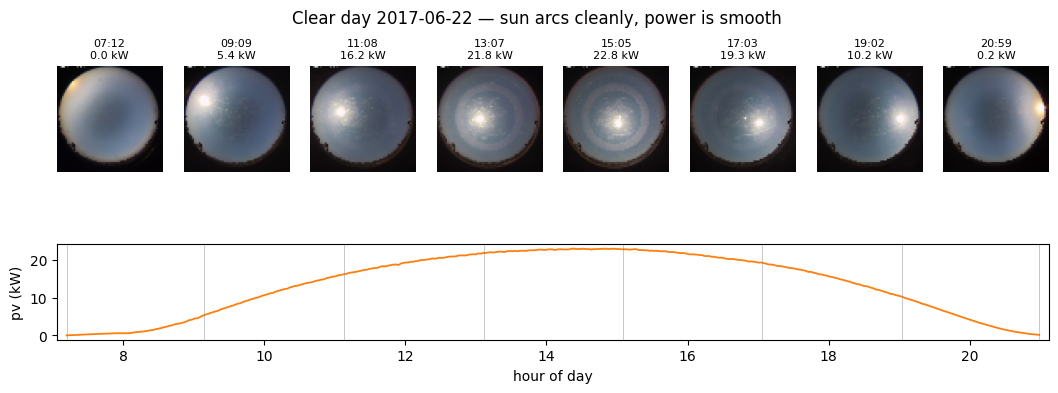

In [11]:
def day_view(day, k=8, title=""):
    """Filmstrip of k frames across one day, with that day's power curve below."""
    day = pd.Timestamp(day).date()
    d = imgs[imgs["date"].dt.date == day].sort_values("mod")   # date match is tz-agnostic
    picks = d.iloc[np.linspace(0, len(d) - 1, k).astype(int)]
    fig = plt.figure(figsize=(1.6 * k, 3.8))
    gs = fig.add_gridspec(2, k, height_ratios=[3, 2], hspace=0.45)
    for j, (_, row) in enumerate(picks.iterrows()):
        m = int(row["mod"])                                    # `.mod` is a pandas method -> use [ ]
        ax = fig.add_subplot(gs[0, j])
        ax.imshow(decode(row["image"])); ax.axis("off")
        ax.set_title(f"{m // 60:02d}:{m % 60:02d}\n{row['pv']:.1f} kW", fontsize=8)
    axc = fig.add_subplot(gs[1, :])
    axc.plot(d["mod"] / 60, d["pv"], lw=1.3, color="C1")
    for _, row in picks.iterrows():
        axc.axvline(int(row["mod"]) / 60, color="gray", lw=.6, alpha=.5)   # mark sampled frames
    axc.set_xlabel("hour of day"); axc.set_ylabel("pv (kW)"); axc.margins(x=.01)
    fig.suptitle(title, fontsize=12); plt.show()

day_view("2017-06-22", title="Clear day 2017-06-22 — sun arcs cleanly, power is smooth")

### The same view on a cloudy day

Now the most volatile day in this shard. Clouds drift across the lens and power
spikes up and down minute to minute — exactly the ramps a pure-`pv` model cannot
see coming, but that are plainly visible in the sky.

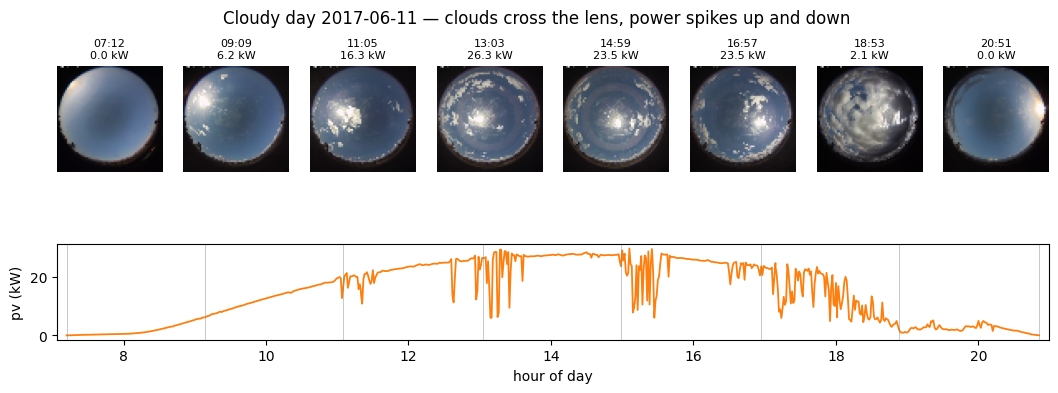

In [12]:
day_view("2017-06-11", title="Cloudy day 2017-06-11 — clouds cross the lens, power spikes up and down")

### Does a simple pixel summary predict power?

The honest test: collapse each frame to one number — its mean brightness — and plot it
against power. It **barely correlates** (the scatter is a blob). Clouds are bright *white*,
so a bright frame can mean clear midday **or** thick cloud. The predictive signal lives in the
**spatial structure** — where the sun is, where clouds sit and drift — which a single scalar
throws away. That is exactly why image-based forecasting uses a **CNN over the frame**, not a
summary statistic.

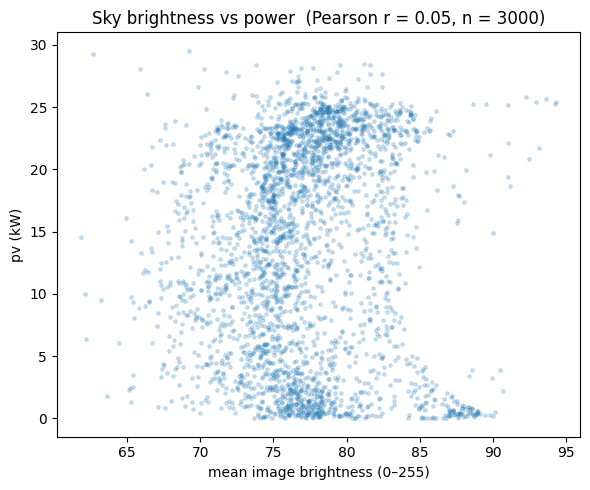

mean brightness alone barely tracks power (r = 0.05): clouds are bright-white too, so one scalar is ambiguous — the signal is spatial (sun & cloud position), a job for a CNN.


In [13]:
samp = imgs.sample(3000, random_state=0)
brightness = samp["image"].map(lambda r: decode(r).mean())   # mean pixel value, 0-255
r = np.corrcoef(brightness, samp["pv"])[0, 1]

plt.figure(figsize=(6, 5))
plt.scatter(brightness, samp["pv"], s=6, alpha=.2)
plt.xlabel("mean image brightness (0–255)"); plt.ylabel("pv (kW)")
plt.title(f"Sky brightness vs power  (Pearson r = {r:.2f}, n = 3000)")
plt.tight_layout(); plt.show()
print(f"mean brightness alone barely tracks power (r = {r:.2f}): clouds are bright-white too, "
      "so one scalar is ambiguous — the signal is spatial (sun & cloud position), a job for a CNN.")

### What the images add

- Frames are **64×64 RGB**, one per `pv` timestamp, **row-aligned to `labels/`** — join on `time` or by row order.
- **Clear day** = smooth sun arc + smooth power; **cloudy day** = clouds crossing the lens + violent ramps (visible in the filmstrips above).
- A single scalar (**mean brightness**) barely correlates with power (r≈0.05) — clouds are bright too, so brightness is ambiguous. The signal is **spatial**, not a summary.
- Hence **multimodal / image-based short-term forecasting**: feed a **CNN embedding** of the sky image (which captures sun & cloud position and motion) alongside the `pv` history, so the model can *see* clouds arriving. The same `vanilla_transformer` windowing still applies — just add the image features per timestep.